# H4-2 — 상위 지출군 × 신규/재활성화 교차분석

**목적**: H4-1에서 "매출 증가는 나머지80% 가구가 견인했다"는 게 확인됐다.
이 성장이 (a)신규/재활성화 가구가 새로 들어와서 채운 것인지, (b)원래 있던 가구가 자연 성장한 것인지 확인한다.

**라벨 정의 (합의된 기준, 내일 팀 확정 시 이 셀들만 수정하면 됨)**
- 신규: 첫 구매일이 안정구간 시작 이후인 가구 (안정구간 시작 시점엔 아직 고객이 아니었음)
- 재활성화: 신규가 아니면서, 구매 공백(gap)이 13주(91일) 이상이었던 적이 있는 가구
- 기존: 위 두 조건에 모두 해당하지 않는 가구

**H4-1과의 차이**: H4-1의 `panel`은 초반·후반 구간 모두 거래가 있는 가구만 남긴 좁은 표본이었다.
신규/재활성화 가구는 정의상 초반 구간에 거래가 없을 수 있으므로, 여기서는 **안정구간에 존재하는 전체 가구**로 넓혀서 다시 구성한다.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from scipy import stats

candidates = ["Malgun Gothic", "NanumGothic", "AppleGothic"]
available = {f.name for f in fm.fontManager.ttflist}
font_name = next((c for c in candidates if c in available), None)
if font_name:
    plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

pd.set_option('display.max_columns', 100)

DATA_DIR = "data/"
tx = pd.read_csv(DATA_DIR + "transaction_data.csv")

STABLE_MIN_WEEK = 17
STABLE_MAX_WEEK = 99
EARLY_N = 10
TOP_X_PCT = 20
REACTIVATION_GAP_DAYS = 13 * 7  # 13주 = 91일

tx_stable = tx[(tx["WEEK_NO"] >= STABLE_MIN_WEEK) & (tx["WEEK_NO"] <= STABLE_MAX_WEEK)].copy()
print(f"안정구간 가구 수: {tx_stable['household_key'].nunique():,}")


안정구간 가구 수: 2,492


## 1. 신규 가구 판정

전체 관측기간(tx, DAY 1~711 전체) 기준 첫 구매일을 구하고, 안정구간 시작일(week 17) 이후에 첫 구매한 가구를 신규로 분류.


In [2]:
# 안정구간 시작일(day 기준) 확인
stable_start_day = tx.loc[tx["WEEK_NO"] >= STABLE_MIN_WEEK, "DAY"].min()
print(f"안정구간(week {STABLE_MIN_WEEK}) 시작일: DAY {stable_start_day}")

# 가구별 전체 관측기간 기준 첫 구매일
first_purchase_day = tx.groupby("household_key")["DAY"].min().rename("first_purchase_day")

is_new = first_purchase_day > stable_start_day
print(f"\n신규 가구 수: {is_new.sum():,} / 전체 {len(first_purchase_day):,}")


안정구간(week 17) 시작일: DAY 111

신규 가구 수: 209 / 전체 2,500


## 2. 재활성화 가구 판정

신규가 아닌 가구 중, 전체 관측기간 내 구매 공백(gap)이 13주(91일) 이상이었던 적이 있는 가구.
(gap_analysis.ipynb에서 쓴 것과 동일한 계산 방식 재사용)


In [3]:
purchase_days = (
    tx[["household_key", "DAY"]]
    .drop_duplicates()
    .sort_values(["household_key", "DAY"])
)
purchase_days["prev_day"] = purchase_days.groupby("household_key")["DAY"].shift(1)
purchase_days["gap_days"] = purchase_days["DAY"] - purchase_days["prev_day"]

max_gap_days = purchase_days.groupby("household_key")["gap_days"].max().rename("max_gap_days")
max_gap_days = max_gap_days.fillna(0)  # 거래가 1건뿐이면 gap 없음 → 0으로 처리

has_long_gap = max_gap_days >= REACTIVATION_GAP_DAYS
print(f"13주 이상 공백 이력이 있는 가구 수: {has_long_gap.sum():,}")


13주 이상 공백 이력이 있는 가구 수: 789


## 3. 세 카테고리로 라벨링 (MECE 확인)

우선순위: 신규 → 재활성화 → 기존 (신규가 아니면서 장기공백 이력이 있으면 재활성화)


In [4]:
labels = pd.DataFrame(index=first_purchase_day.index)
labels["is_new"] = is_new
labels["has_long_gap"] = has_long_gap.reindex(labels.index).fillna(False)

def classify(row):
    if row["is_new"]:
        return "신규"
    elif row["has_long_gap"]:
        return "재활성화"
    else:
        return "기존"

labels["customer_type"] = labels.apply(classify, axis=1)

print("고객 유형별 가구 수 (전체 관측기간 기준)")
print(labels["customer_type"].value_counts())
print(f"\n합계 확인: {labels['customer_type'].value_counts().sum():,} (전체 가구 {len(labels):,}와 일치해야 함)")


고객 유형별 가구 수 (전체 관측기간 기준)
customer_type
기존      1565
재활성화     726
신규       209
Name: count, dtype: int64

합계 확인: 2,500 (전체 가구 2,500와 일치해야 함)


## 4. 안정구간 기준 초반 지출액 + 상위 20% 그룹 (넓은 데이터셋)

안정구간에 존재하는 전체 가구 대상으로, 초반 구간(week 17~26) 지출액을 계산.
초반 구간에 거래가 없는 가구(신규/늦은 재활성화 등)는 지출액 0으로 처리 — 자동으로 나머지80%에 속하게 됨.


In [5]:
stable_households = tx_stable["household_key"].unique()

early_window = tx_stable[
    (tx_stable["WEEK_NO"] >= STABLE_MIN_WEEK) &
    (tx_stable["WEEK_NO"] < STABLE_MIN_WEEK + EARLY_N)
]
sales_early_full = early_window.groupby("household_key")["SALES_VALUE"].sum()

# 넓은 패널: 안정구간에 존재하는 모든 가구, 초반 지출액 0으로 채움
panel_wide = pd.DataFrame(index=stable_households)
panel_wide["sales_early"] = sales_early_full.reindex(panel_wide.index).fillna(0)
panel_wide = panel_wide.join(labels[["customer_type"]], how="left")

print(f"넓은 패널 가구 수: {len(panel_wide):,}")
print(f"customer_type 결측(라벨링 안 된 가구): {panel_wide['customer_type'].isna().sum()}")

# 상위 20% 컷오프 (넓은 패널 전체 기준 — 초반 지출 0인 가구 포함)
cutoff_value = panel_wide["sales_early"].quantile(1 - TOP_X_PCT/100)
panel_wide["group"] = np.where(panel_wide["sales_early"] >= cutoff_value, "상위20%", "나머지80%")

print(f"\n상위20% 컷오프(초반 지출액): {cutoff_value:.2f}")
print(panel_wide["group"].value_counts())


넓은 패널 가구 수: 2,492
customer_type 결측(라벨링 안 된 가구): 0

상위20% 컷오프(초반 지출액): 535.29
group
나머지80%    1993
상위20%      499
Name: count, dtype: int64


## 5. 2×2 교차표 구성

신규+재활성화를 하나로 묶어 원래 계획대로 2×2 표를 만들고, 참고용으로 3분류(신규/재활성화/기존) 원본 교차표도 같이 확인.


In [6]:
# 참고용: 3분류 원본 교차표
crosstab_3cat = pd.crosstab(panel_wide["group"], panel_wide["customer_type"])
print("참고용 - 3분류 교차표")
print(crosstab_3cat)


참고용 - 3분류 교차표
customer_type    기존   신규  재활성화
group                         
나머지80%         1127  175   691
상위20%           431   34    34


In [7]:
# 신규+재활성화를 하나로 묶은 2x2 교차표
panel_wide["new_or_reactivated"] = panel_wide["customer_type"].isin(["신규", "재활성화"])
panel_wide["cohort"] = np.where(panel_wide["new_or_reactivated"], "신규·재활성화", "기존")

crosstab_2x2 = pd.crosstab(panel_wide["group"], panel_wide["cohort"])
print("2x2 교차표 (가구 수)")
print(crosstab_2x2)

print("\n행 기준 비율(%) - 각 지출그룹 내 신규·재활성화 비중")
print((crosstab_2x2.div(crosstab_2x2.sum(axis=1), axis=0) * 100).round(1))


2x2 교차표 (가구 수)
cohort    기존  신규·재활성화
group                
나머지80%  1127      866
상위20%    431       68

행 기준 비율(%) - 각 지출그룹 내 신규·재활성화 비중
cohort    기존  신규·재활성화
group                
나머지80%  56.5     43.5
상위20%   86.4     13.6


## 6. 기대빈도 확인 → 검정 방법 결정

모든 셀 기대빈도 ≥5 이면 카이제곱, 하나라도 <5 이면 Fisher's exact test.


In [8]:
chi2_stat, chi2_p, dof, expected = stats.chi2_contingency(crosstab_2x2)

print("기대빈도표")
print(pd.DataFrame(expected, index=crosstab_2x2.index, columns=crosstab_2x2.columns).round(1))

min_expected = expected.min()
print(f"\n최소 기대빈도: {min_expected:.2f}")

use_fisher = min_expected < 5
print(f"→ {'Fisher exact test 사용' if use_fisher else '카이제곱 검정 사용 가능'}")


기대빈도표
cohort      기존  신규·재활성화
group                  
나머지80%  1246.0    747.0
상위20%    312.0    187.0

최소 기대빈도: 187.02
→ 카이제곱 검정 사용 가능


## 7. 검정 실행 + 효과크기

- 카이제곱 사용 시: Cramér's V
- Fisher's exact 사용 시: 오즈비(Odds Ratio) + 95% CI (로그오즈비의 정규근사 기반)


In [9]:
n_total = crosstab_2x2.values.sum()

if use_fisher:
    # 2x2 표 순서: crosstab_2x2 행=[나머지80%, 상위20%], 열=[기존, 신규·재활성화] (알파벳/가나다 순 정렬 주의)
    print("교차표 행/열 순서 확인:")
    print(crosstab_2x2)

    odds_ratio, p_value = stats.fisher_exact(crosstab_2x2.values)

    # 오즈비 신뢰구간 (Haldane-Anscombe 보정: 0 셀 있을 경우 대비 +0.5)
    a, b = crosstab_2x2.values[0]
    c, d = crosstab_2x2.values[1]
    if 0 in [a, b, c, d]:
        a, b, c, d = a+0.5, b+0.5, c+0.5, d+0.5
        odds_ratio = (a*d) / (b*c)

    log_or = np.log(odds_ratio)
    se_log_or = np.sqrt(1/a + 1/b + 1/c + 1/d)
    ci_low = np.exp(log_or - 1.96*se_log_or)
    ci_high = np.exp(log_or + 1.96*se_log_or)

    print(f"\n[Fisher's exact test]")
    print(f"p-value = {p_value:.6f}")
    print(f"오즈비(OR) = {odds_ratio:.3f}")
    print(f"95% CI = ({ci_low:.3f}, {ci_high:.3f})")

else:
    n = n_total
    r, k = crosstab_2x2.shape
    cramers_v = np.sqrt(chi2_stat / (n * (min(r, k) - 1)))

    print(f"[카이제곱 독립성 검정]")
    print(f"chi2 statistic = {chi2_stat:.3f}, dof = {dof}")
    print(f"p-value = {chi2_p:.6f}")
    print(f"효과크기(Cramér's V) = {cramers_v:.3f}")


[카이제곱 독립성 검정]
chi2 statistic = 150.225, dof = 1
p-value = 0.000000
효과크기(Cramér's V) = 0.246


## 8. 결과 요약 및 해석 가이드

- p-value가 유의(<0.05)하고 위 5번 비율표에서 **상위20%의 신규·재활성화 비중이 나머지80%보다 낮다**면
  → "매출 증가를 견인한 나머지80%에는 신규·재활성화 가구가 상대적으로 더 많이 섞여 있다"는 근거
- 반대로 비율에 큰 차이가 없거나 유의하지 않다면
  → 나머지80%의 성장은 신규·재활성화 유입보다는 기존 가구의 자연스러운 지출 증가일 가능성


In [10]:
print("최종 비율 비교 (그룹 내 신규·재활성화 비중)")
ratio_table = (crosstab_2x2.div(crosstab_2x2.sum(axis=1), axis=0) * 100).round(1)
print(ratio_table)

print(f"\n검정 결론: {'유의함 (연관 있음)' if (p_value if use_fisher else chi2_p) < 0.05 else '유의하지 않음 (연관 근거 부족)'}")


최종 비율 비교 (그룹 내 신규·재활성화 비중)
cohort    기존  신규·재활성화
group                
나머지80%  56.5     43.5
상위20%   86.4     13.6

검정 결론: 유의함 (연관 있음)


## 9. 신규·재활성화 가구의 실제 기여분 계산

지금까지(2×2 교차표)는 "연관이 있다"까지만 확인했다. 여기서는 한 걸음 더 나가서,
**나머지80% 그룹의 매출 증가분 중 실제로 얼마가 신규·재활성화 가구에서 나왔는지**를 금액으로 직접 분해한다.

이게 있어야 "신규·재활성화가 많이 섞여있다"는 상관관계를 넘어서, "그래서 매출 증가에 실제로 얼마나 기여했는가"를 말할 수 있다.


In [12]:
# panel_wide에 후반 구간 지출액도 채워서 diff 계산 (이전 셀에서는 sales_early만 있었음)
late_window = tx_stable[
    (tx_stable["WEEK_NO"] > STABLE_MAX_WEEK - EARLY_N) &
    (tx_stable["WEEK_NO"] <= STABLE_MAX_WEEK)
]
sales_late_full = late_window.groupby("household_key")["SALES_VALUE"].sum()

panel_wide["sales_late"] = sales_late_full.reindex(panel_wide.index).fillna(0)
panel_wide["diff"] = panel_wide["sales_late"] - panel_wide["sales_early"]

print("panel_wide 최종 컬럼:", list(panel_wide.columns))
panel_wide[["sales_early", "sales_late", "diff", "group", "cohort", "customer_type"]].head()


panel_wide 최종 컬럼: ['sales_early', 'customer_type', 'group', 'new_or_reactivated', 'cohort', 'sales_late', 'diff']


,sales_early,sales_late,diff,group,cohort,customer_type
1423,172.56,143.82,-28.74,나머지80%,기존,기존
232,2426.34,335.79,-2090.55,상위20%,기존,기존
2055,29.57,556.10,526.53,나머지80%,신규·재활성화,재활성화
2318,2596.66,80.84,-2515.82,상위20%,기존,기존
746,166.00,0.00,-166.00,나머지80%,신규·재활성화,재활성화


### 9-1. 나머지80% 그룹 내 — cohort별 diff 합계 및 기여 비중

나머지80% 그룹 전체의 총 diff(순증가분)를 100%로 놓고, 그중 신규·재활성화 vs 기존이 각각 몇 %를 차지하는지 계산.


In [13]:
rest_group = panel_wide[panel_wide["group"] == "나머지80%"].copy()

total_diff_rest = rest_group["diff"].sum()
contribution = rest_group.groupby("cohort")["diff"].agg(["sum", "mean", "median", "count"])
contribution["기여비율(%)"] = (contribution["sum"] / total_diff_rest * 100).round(1)

print(f"나머지80% 그룹 전체 순증가분 합계: {total_diff_rest:,.0f}")
print()
contribution


나머지80% 그룹 전체 순증가분 합계: 193,280



,sum,mean,median,count,기여비율(%)
cohort,,,,,
기존,135200.32,119.964791,51.780,1127,70.0
신규·재활성화,58079.24,67.066097,10.255,866,30.0


### 9-2. 전체 인구(상위20%+나머지80%) 기준 — cohort별 기여분

그룹 구분 없이 전체 안정구간 가구를 대상으로도 동일하게 확인. H4-1에서 확인된 "전체 순증가"에서
신규·재활성화가 차지하는 몫을 그림.


In [14]:
total_diff_all = panel_wide["diff"].sum()
contribution_all = panel_wide.groupby("cohort")["diff"].agg(["sum", "mean", "median", "count"])
contribution_all["기여비율(%)"] = (contribution_all["sum"] / total_diff_all * 100).round(1)

print(f"전체 가구 순증가분 합계: {total_diff_all:,.0f}")
print()
contribution_all


전체 가구 순증가분 합계: 126,232



,sum,mean,median,count,기여비율(%)
cohort,,,,,
기존,95773.35,61.471983,24.345,1558,75.9
신규·재활성화,30458.83,32.611167,3.025,934,24.1


### 9-3. cohort별 diff 분포 통계 검증 (나머지80% 내에서, 신규·재활성화 vs 기존)

"신규·재활성화 가구가 정말로 기존 가구보다 diff가 더 큰가"를 비모수 검정으로 확인 (Mann-Whitney U).
표본이 비정규 분포일 가능성이 높으므로 정규성 확인 후 진행.


In [15]:
new_react_diff = rest_group.loc[rest_group["cohort"] == "신규·재활성화", "diff"].values
existing_diff  = rest_group.loc[rest_group["cohort"] == "기존", "diff"].values

# 정규성 (참고용)
for name, arr in [("신규·재활성화", new_react_diff), ("기존", existing_diff)]:
    stat, p = stats.shapiro(arr) if len(arr) < 5000 else stats.normaltest(arr)
    print(f"{name}: n={len(arr)}, 정규성 p={p:.6f} ({'기각' if p<0.05 else '기각안됨'})")

u_stat, p_mw = stats.mannwhitneyu(new_react_diff, existing_diff, alternative='two-sided')
n1, n2 = len(new_react_diff), len(existing_diff)
rank_biserial = 1 - (2*u_stat) / (n1*n2)
common_language = u_stat / (n1*n2)

print(f"\n[Mann-Whitney U] 신규·재활성화 vs 기존 (나머지80% 내)")
print(f"U statistic = {u_stat:.2f}, p-value = {p_mw:.6f}")
print(f"효과크기(rank-biserial) = {rank_biserial:.3f}")
print(f"공통언어효과크기 = {common_language:.3f}")
print(f"중앙값 diff - 신규·재활성화: {np.median(new_react_diff):.2f}, 기존: {np.median(existing_diff):.2f}")


신규·재활성화: n=866, 정규성 p=0.000000 (기각)
기존: n=1127, 정규성 p=0.000000 (기각)

[Mann-Whitney U] 신규·재활성화 vs 기존 (나머지80% 내)
U statistic = 445820.00, p-value = 0.000928
효과크기(rank-biserial) = 0.086
공통언어효과크기 = 0.457
중앙값 diff - 신규·재활성화: 10.26, 기존: 51.78


### 9-4. 시각화 — cohort별 기여분 비교

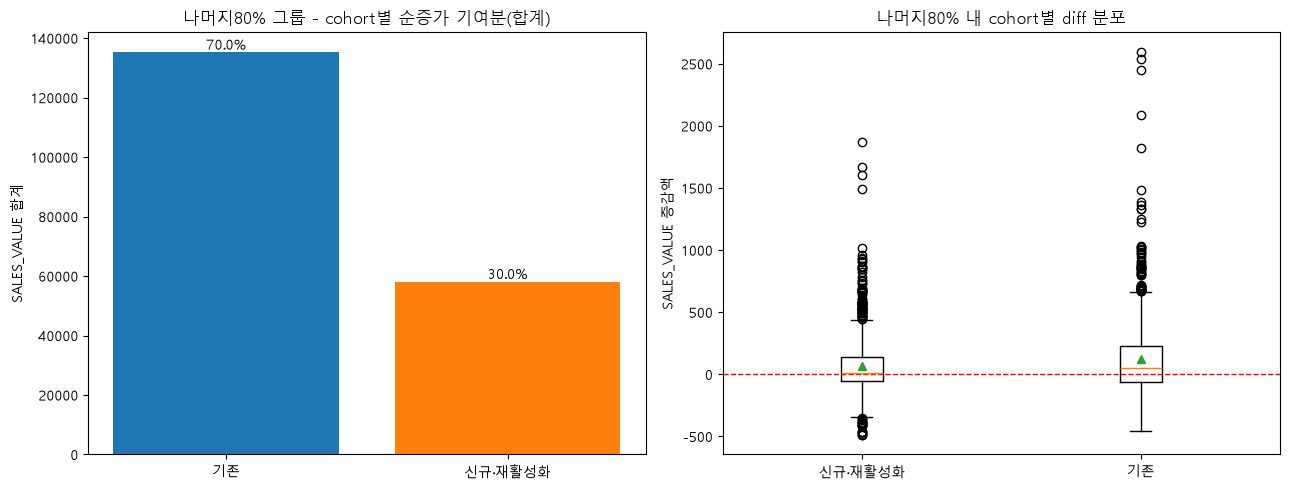

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(contribution.index, contribution["sum"], color=['C0', 'C1'])
axes[0].axhline(0, color='gray', linewidth=0.8)
axes[0].set_title("나머지80% 그룹 - cohort별 순증가 기여분(합계)")
axes[0].set_ylabel("SALES_VALUE 합계")

axes[0].bar_label(axes[0].containers[0], labels=[f"{v:.1f}%" for v in contribution["기여비율(%)"]])

axes[1].boxplot([new_react_diff, existing_diff], tick_labels=["신규·재활성화", "기존"], showmeans=True)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_title("나머지80% 내 cohort별 diff 분포")
axes[1].set_ylabel("SALES_VALUE 증감액")

plt.tight_layout()
plt.show()


### 9-5. 해석 가이드

- **9-1 기여비율**: 나머지80%의 총 순증가분 중 신규·재활성화가 차지하는 비중이 인원 비중(43.5%)보다 훨씬 크다면
  → "단순히 숫자가 많아서"가 아니라 "1인당 기여도 자체가 크다"는 뜻으로, 인과적 해석에 더 힘이 실림
  반대로 인원 비중과 기여 비중이 비슷하면 → 그냥 머릿수 효과일 가능성
- **9-3 검정**: p<0.05이고 신규·재활성화의 중앙값 diff가 기존보다 유의하게 크다면
  → "신규·재활성화 가구가 실제로 더 크게 늘었다"는 근거가 통계적으로 뒷받침됨
- 이 두 가지가 모두 확인되면, H4-2의 결론을 "연관이 있다"에서 한 걸음 더 나아가
  "신규·재활성화 유입이 매출 증가에 실질적으로 기여했다"는 쪽으로 서술할 수 있음
